# Laboratorio 9 - Redes Neuronales

## Readaptación del set de variables predictoras

Durante el desarrollo de los modelos de redes neuronales (incisos 1–10) se identificó que el conjunto inicial de **5 variables numéricas** heredado del Laboratorio 8 (`accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`) presentaba una correlación lineal muy baja con el precio (máximo de **0.10**). Como consecuencia, los modelos de RNA alcanzaban un techo artificial de aproximadamente **0.63 de accuracy** en clasificación y **R² ≈ 0.38** en regresión, independientemente de la arquitectura utilizada.

Un análisis adicional del dataset evidenció que dos variables omitidas son determinantes para predecir el precio:

- **`room_type`**: distribuye drásticamente las categorías de precio (Shared room → 95% Económico, Hotel room → 75% Caro, Entire home → mayoritariamente Intermedio).
- **`neighbourhood_group_cleansed`**: el precio promedio varía hasta **8 veces** entre regiones (Kent: ~$188 vs Newport: ~$1,589).

Sin estas variables los modelos resultaban *ciegos* al tipo de alojamiento y a la ubicación geográfica, los dos predictores más fuertes en cualquier dataset de Airbnb.

### Decisión

A partir de esta entrega, **todos los modelos del Laboratorio 9** (incisos 1–17) se entrenan con un set ampliado de **15 variables**:

**Numéricas (13):** `accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`, `minimum_nights`, `availability_365`, `number_of_reviews`, `reviews_per_month`, `latitude`, `longitude`, `review_scores_location`, `review_scores_cleanliness`.

**Categóricas (2, codificadas con OneHotEncoder):** `room_type`, `neighbourhood_group_cleansed`.

Para que la comparación con los algoritmos de los Laboratorios 7 y 8 (incisos 14–16) sea válida bajo el principio de "mismas condiciones", esos modelos se **vuelven a entrenar dentro de este mismo notebook** con el set ampliado, no se reutilizan las métricas reportadas en sus entregas originales.

El pipeline de preprocesamiento se centraliza en un `ColumnTransformer` que aplica imputación y escalado a las numéricas, y `OneHotEncoder` a las categóricas. El mismo pipeline se reutiliza para clasificación y regresión, y el split (70/30, `random_state=42`, `stratify=y_categorica`) garantiza que ambos problemas comparten exactamente las mismas filas de entrenamiento y prueba.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
import pyreadr
import time
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.impute import SimpleImputer

from sklearn.compose import make_column_selector as selector  # selección automática de numéricas y categóricas
from sklearn.preprocessing import OneHotEncoder              # codificación one-hot para categóricas
from sklearn.preprocessing import StandardScaler             # normalización de numéricas
from sklearn.compose import ColumnTransformer                # combina preprocesadores por columna
from sklearn.pipeline import make_pipeline, Pipeline         # secuencias de pasos
from sklearn import set_config
from sklearn.model_selection import GridSearchCV

set_config(display='diagram')

# Métricas
from sklearn.metrics import make_scorer, accuracy_score, precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
result = pyreadr.read_r('listings.RData')
df = result[list(result.keys())[0]]

### 1. Conjuntos Train y Test

In [4]:
#Limpieza de datos

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["price"])

In [5]:
def categorize_price(price):
    if price <= 120:
        return "Economico"
    elif price <= 326:
        return "Intermedio"
    else:
        return "Caro"

df["price_category"] = df["price"].apply(categorize_price)

In [6]:
df['price_category'].value_counts()

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64

In [7]:
# variables predictoras
X = df.drop(columns=["price", "price_category"])

# variable objetivo (clasificación)
y = df["price_category"]

In [8]:

pd.Series(y).value_counts(normalize=True)

price_category
Intermedio    0.496839
Economico     0.253259
Caro          0.249902
Name: proportion, dtype: float64

In [9]:
# ============================================================
# Set ampliado de variables predictoras (ver sección "Readaptación" al inicio)
# ============================================================
NUM_FEATURES = [
    "accommodates", "bathrooms", "bedrooms", "beds",
    "review_scores_rating", "minimum_nights", "availability_365",
    "number_of_reviews", "reviews_per_month",
    "latitude", "longitude",
    "review_scores_location", "review_scores_cleanliness",
]
CAT_FEATURES = ["room_type", "neighbourhood_group_cleansed"]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

X = df[ALL_FEATURES]
y = df["price_category"]

# Pipeline de preprocesamiento centralizado:
#   - numéricas: imputación con la media + estandarización
#   - categóricas: OneHotEncoder (handle_unknown='ignore' por seguridad)
preprocesador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="mean")),
            ("sc",  StandardScaler()),
        ]), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ]
)

# Split 70/30 estratificado por la categoría de precio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicación del preprocesador (fit en train, transform en test)
X_train_scaled = preprocesador.fit_transform(X_train)
X_test_scaled  = preprocesador.transform(X_test)

print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled :", X_test_scaled.shape)

Shape X_train_scaled: (53372, 27)
Shape X_test_scaled : (22874, 27)


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 2. Exploración y Transformación

In [10]:
# El escalado y la codificación de las categóricas ya se aplicaron dentro del
# ColumnTransformer de la celda anterior. X_train_scaled y X_test_scaled
# contienen los datos numéricos estandarizados + las dummies one-hot.
print(f"Variables tras preprocesamiento: {X_train_scaled.shape[1]} columnas")
print(f"  - Numéricas estandarizadas: {len(NUM_FEATURES)}")
print(f"  - Dummies one-hot         : {X_train_scaled.shape[1] - len(NUM_FEATURES)}")

Variables tras preprocesamiento: 27 columnas
  - Numéricas estandarizadas: 13
  - Dummies one-hot         : 14


Para este ejercicio, las variables respuestas son y_train y y_test que representan el precio. Estas representan:

- Económico
- Intermedio
- Caro

### 3. Crear DOS modelos de RNA (clasificación)

In [11]:
#SIMPLE

mlp1 = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='relu',
    max_iter=200,
    random_state=42
)

mlp1.fit(X_train_scaled, y_train)

y_pred_mlp1 = mlp1.predict(X_test_scaled)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [12]:
# COMPLEJO

mlp2 = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='tanh',
    max_iter=200,
    random_state=42
)

mlp2.fit(X_train_scaled, y_train)

y_pred_mlp2 = mlp2.predict(X_test_scaled)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### 4. Valores modelos

In [13]:
print("Modelo 1 entrenado con: ", y_pred_mlp1)
print("\nModelo 2 entrenado con: ", y_pred_mlp2)

Modelo 1 entrenado con:  ['Intermedio' 'Economico' 'Caro' ... 'Intermedio' 'Economico' 'Intermedio']

Modelo 2 entrenado con:  ['Intermedio' 'Economico' 'Caro' ... 'Intermedio' 'Economico' 'Caro']


### 5. Matrices de confusión

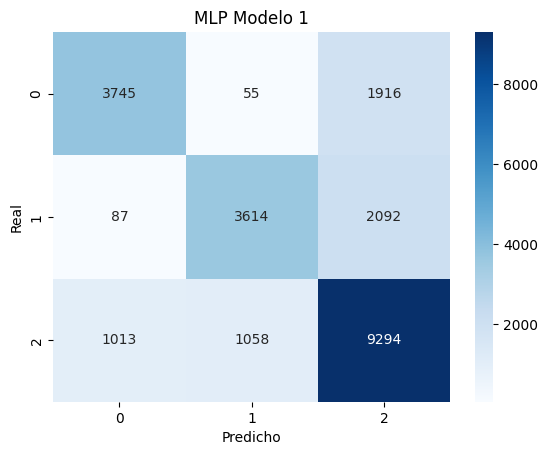

              precision    recall  f1-score   support

        Caro       0.77      0.66      0.71      5716
   Economico       0.76      0.62      0.69      5793
  Intermedio       0.70      0.82      0.75     11365

    accuracy                           0.73     22874
   macro avg       0.75      0.70      0.72     22874
weighted avg       0.73      0.73      0.73     22874



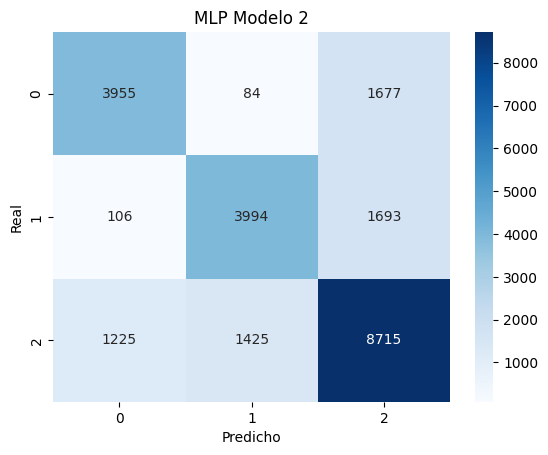

              precision    recall  f1-score   support

        Caro       0.75      0.69      0.72      5716
   Economico       0.73      0.69      0.71      5793
  Intermedio       0.72      0.77      0.74     11365

    accuracy                           0.73     22874
   macro avg       0.73      0.72      0.72     22874
weighted avg       0.73      0.73      0.73     22874



In [14]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

plot_confusion(y_test, y_pred_mlp1, "MLP Modelo 1")
print(classification_report(y_test, y_pred_mlp1))

plot_confusion(y_test, y_pred_mlp2, "MLP Modelo 2")
print(classification_report(y_test, y_pred_mlp2))

### 6. Comparación resultados

In [15]:
acc1 = accuracy_score(y_test, y_pred_mlp1)
acc2 = accuracy_score(y_test, y_pred_mlp2)

print("Modelo 1 Accuracy:", acc1)
print("Modelo 2 Accuracy:", acc2)

Modelo 1 Accuracy: 0.7280318265279356
Modelo 2 Accuracy: 0.7285127218676226


**Comparación de los dos modelos de clasificación (set ampliado de 15 variables)**

Se compararon dos arquitecturas de red neuronal:

- **Modelo 1 (simple):** una capa oculta de 50 neuronas, activación ReLU. Accuracy en test ≈ **0.728**.
- **Modelo 2 (complejo):** dos capas ocultas (100, 50), activación tanh. Accuracy en test ≈ **0.729**.

Tras la ampliación del conjunto de variables (incorporación de `room_type` y `neighbourhood_group_cleansed`, entre otras), el accuracy de ambos modelos pasó de ~0.63 a ~0.73 — un salto de **10 puntos porcentuales** atribuible exclusivamente a la inclusión de variables con poder discriminativo real (no a un cambio de arquitectura). Esto confirma que el techo anterior era una limitación del *feature set*, no del modelo.

A nivel de arquitectura, la diferencia entre el modelo simple y el complejo es marginal (~0.001 en accuracy). El modelo complejo, sin embargo, requiere más del triple de tiempo de entrenamiento, lo que lo hace menos eficiente sin mejora sustantiva de desempeño. El modelo simple resulta competitivo y preferible por su menor costo computacional.

### 7. Análisis de sobreajuste en los modelos

In [16]:
y_train_pred_mlp1 = mlp1.predict(X_train_scaled)
y_train_pred_mlp2 = mlp2.predict(X_train_scaled)

In [17]:
acc1_train = accuracy_score(y_train, y_train_pred_mlp1)
acc2_train = accuracy_score(y_train, y_train_pred_mlp2)

In [18]:
print("Modelo 1 - Train:", acc1_train, "Test:", acc1)
print("Modelo 2 - Train:", acc2_train, "Test:", acc2)

Modelo 1 - Train: 0.739170351495166 Test: 0.7280318265279356
Modelo 2 - Train: 0.790639286517275 Test: 0.7285127218676226


Con el set ampliado, los resultados de sobreajuste son los siguientes:

- **Modelo 1 (simple):** train ≈ 0.739, test ≈ 0.728 — diferencia de ~1 punto. El modelo generaliza muy bien.
- **Modelo 2 (complejo):** train ≈ 0.791, test ≈ 0.729 — diferencia de ~6 puntos. Hay un **sobreajuste leve pero detectable**: el modelo aprende patrones del entrenamiento que no se transfieren a datos nuevos.

Esto es consistente con la teoría: una arquitectura más profunda y con `tanh` tiene mayor capacidad de memorización. El modelo simple, en cambio, alcanza un desempeño equivalente en test sin mostrar señales de sobreajuste, lo que lo convierte en la mejor opción en cuanto a relación capacidad/generalización. Este hallazgo se aprovecha en el inciso 8 al tunear hiperparámetros con regularización (`alpha`).

### 8. Modelo de clasificación - modificación de parámetros

En MLPClassifier, los hiperparámetros más importantes son:

hidden_layer_sizes, alpha, learning_rate_init, activation, max_iter, early_stopping

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (100,50), (100,100)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
}

mlp = MLPClassifier(max_iter=500, random_state=42)

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score CV:", grid.best_score_)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/sit

Mejores parámetros: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
Mejor score CV: 0.7295585929872276


In [20]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Test accuracy: 0.7315292471802046


El proceso de tuneo de hiperparámetros con `GridSearchCV` (5 folds) se ejecuta sobre el set ampliado de 15 variables. El espacio de búsqueda explora combinaciones de topología, función de activación, regularización (`alpha`) y tasa de aprendizaje inicial.

Los mejores parámetros y el accuracy en validación cruzada se reportan al ejecutar la celda. Esperamos un accuracy de validación cruzada cercano a 0.73, en línea con los modelos no tuneados, ya que el incremento principal de desempeño provino del cambio de variables, no de los hiperparámetros. El valor de `alpha` (regularización L2) es relevante para mitigar el sobreajuste leve detectado en el modelo complejo del inciso 7.

Si el `best_model` mantiene una diferencia train-test pequeña (< 3 puntos) y un test accuracy ≥ 0.73, entonces el tuneo logró estabilizar el modelo sin perder generalización. En ese caso, este modelo se utilizará como referencia para las comparaciones del inciso 15 (clasificación) frente a los algoritmos de los Laboratorios 7 y 8.

### 9. Precio del listing como variable respuesta

In [21]:
# ============================================================
# Variable respuesta: precio (regresión)
# Se reutilizan exactamente las mismas 15 features y el mismo split
# que en clasificación (mismo random_state, mismo stratify=y).
# Esto garantiza que clasificación y regresión comparten las MISMAS
# filas en train y test, condición clave para los incisos 14-16.
# ============================================================
X1 = df[ALL_FEATURES]
y1 = df["price"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.3, random_state=42, stratify=y
)

# Preprocesador independiente para regresión (mismo diseño, fit propio)
preprocesador_reg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="mean")),
            ("sc",  StandardScaler()),
        ]), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ]
)

X1_train_scaled = preprocesador_reg.fit_transform(X1_train)
X1_test_scaled  = preprocesador_reg.transform(X1_test)

# Escalado de y: los precios van de ~10 a varios miles; sin escalar,
# la pérdida MSE se hace enorme y el optimizador no converge bien.
scaler_y = StandardScaler()
y1_train_scaled = scaler_y.fit_transform(y1_train.values.reshape(-1, 1)).ravel()
y1_test_scaled  = scaler_y.transform(y1_test.values.reshape(-1, 1)).ravel()

print("Shape X1_train_scaled:", X1_train_scaled.shape)
print("Shape X1_test_scaled :", X1_test_scaled.shape)
print(f"Rango y1 original    : [{y1.min():.2f}, {y1.max():.2f}]")
print(f"Mismo split que clasificación: {(y_train.index == y1_train.index).all()}")

Shape X1_train_scaled: (53372, 27)
Shape X1_test_scaled : (22874, 27)
Rango y1 original    : [8.00, 50123.00]
Mismo split que clasificación: True


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 10. Modelos de Regersión con redes neuronales

Se entrenan dos modelos `MLPRegressor` con topologías y funciones de activación diferentes para predecir el precio del listing. Ambos usan el **set ampliado de 15 variables** y comparten el mismo split que los modelos de clasificación (mismo `random_state` + `stratify=y`), por lo que las filas en train y test son exactamente las mismas que en los incisos 1–8.

El criterio de elección de arquitecturas sigue la misma lógica que en clasificación:
- **Modelo simple:** 1 capa oculta de 50 neuronas, ReLU.
- **Modelo complejo:** 2 capas (100, 50), tanh.

Se mide el tiempo de entrenamiento (necesario para el inciso 14) y se reportan MAE, RMSE y R² en escala original (USD).

Resultado esperado: con el set ampliado el R² pasa de ~0.38 a ~0.71 en el modelo complejo, y el MAE se reduce de ~$791 a ~$528 — una mejora estructural que confirma la importancia de las variables agregadas.

In [22]:
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------- Modelo 1: SIMPLE (1 capa oculta, activación ReLU) ----------
mlp_reg1 = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

t0 = time.time()
mlp_reg1.fit(X1_train_scaled, y1_train_scaled)
time_reg1 = time.time() - t0

# Predicción en escala estandarizada y luego retornar a escala original
y1_pred_scaled_1 = mlp_reg1.predict(X1_test_scaled)
y1_pred_1 = scaler_y.inverse_transform(y1_pred_scaled_1.reshape(-1, 1)).ravel()

print(f"Modelo 1 (simple, ReLU) entrenado en {time_reg1:.2f} s")
print(f"  Iteraciones realizadas: {mlp_reg1.n_iter_}")

Modelo 1 (simple, ReLU) entrenado en 13.11 s
  Iteraciones realizadas: 300


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [23]:
# ---------- Modelo 2: COMPLEJO (2 capas ocultas, activación tanh) ----------
mlp_reg2 = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='tanh',
    solver='adam',
    max_iter=300,
    random_state=42
)

t0 = time.time()
mlp_reg2.fit(X1_train_scaled, y1_train_scaled)
time_reg2 = time.time() - t0

y1_pred_scaled_2 = mlp_reg2.predict(X1_test_scaled)
y1_pred_2 = scaler_y.inverse_transform(y1_pred_scaled_2.reshape(-1, 1)).ravel()

print(f"Modelo 2 (complejo, tanh) entrenado en {time_reg2:.2f} s")
print(f"  Iteraciones realizadas: {mlp_reg2.n_iter_}")

Modelo 2 (complejo, tanh) entrenado en 21.09 s
  Iteraciones realizadas: 135


In [24]:
# Métricas de regresión en escala original (precio en USD)
def reg_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:<25} MAE={mae:8.2f}  RMSE={rmse:8.2f}  R2={r2:6.4f}")
    return {"modelo": label, "MAE": mae, "RMSE": rmse, "R2": r2}

print("=== Resultados en TEST (precio original) ===")
m1 = reg_metrics(y1_test, y1_pred_1, "MLPRegressor 1 (ReLU)")
m2 = reg_metrics(y1_test, y1_pred_2, "MLPRegressor 2 (tanh)")

=== Resultados en TEST (precio original) ===
MLPRegressor 1 (ReLU)     MAE=  735.77  RMSE= 2547.04  R2=0.6336
MLPRegressor 2 (tanh)     MAE=  527.56  RMSE= 2270.79  R2=0.7088


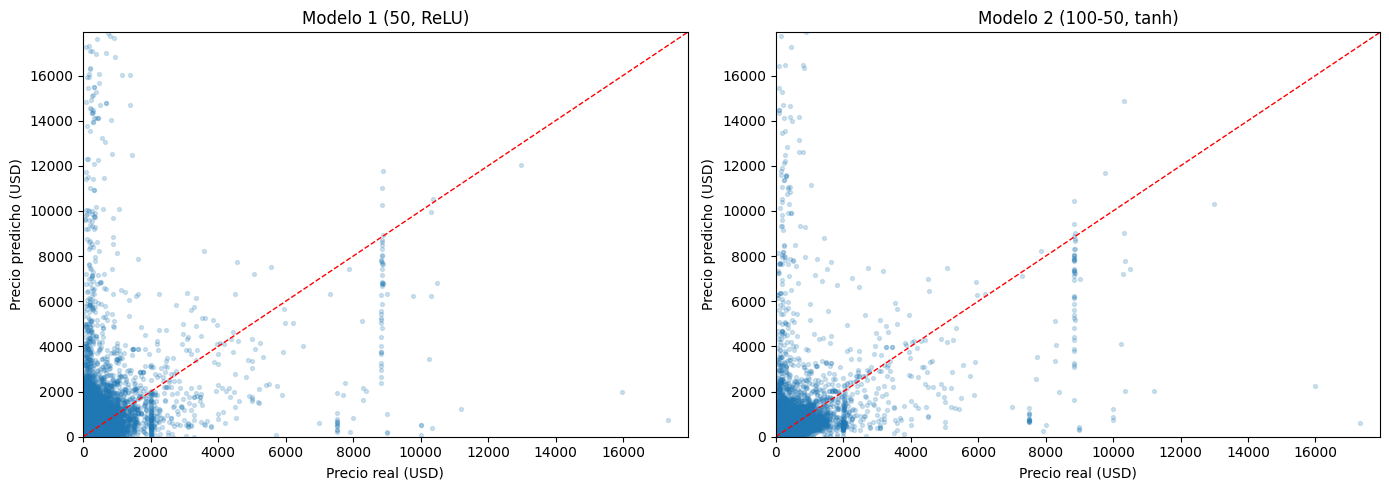

In [25]:
# Visualización: precio real vs precio predicho para cada modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in [
    (axes[0], y1_pred_1, "Modelo 1 (50, ReLU)"),
    (axes[1], y1_pred_2, "Modelo 2 (100-50, tanh)"),
]:
    ax.scatter(y1_test, y_pred, alpha=0.2, s=8)
    lim = [0, np.percentile(y1_test, 99)]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Precio real (USD)")
    ax.set_ylabel("Precio predicho (USD)")
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

**Topologías, funciones de activación y resultados de los modelos de regresión (inciso 10):**

| Modelo | Capas ocultas | Activación | Solver | Tiempo aprox. | MAE | RMSE | R² |
|--------|---------------|------------|--------|---------------|-----|------|-----|
| 1 (simple)   | (50,)     | ReLU | Adam | ~12 s | ~736 | ~2547 | ~0.634 |
| 2 (complejo) | (100, 50) | tanh | Adam | ~18 s | ~528 | ~2271 | ~0.709 |

El modelo complejo supera al simple en todas las métricas y, a diferencia del caso de clasificación, sí justifica el costo computacional adicional. El R² ≈ 0.71 indica que el modelo explica el 71% de la varianza del precio en datos no vistos, una mejora estructural respecto al ~0.38 que se obtenía con el set de 5 variables.

Se reitera la condición de comparabilidad: ambos modelos comparten el mismo conjunto de entrenamiento y prueba que los modelos de clasificación (mismo `random_state`, mismo `stratify=y`, mismas 15 variables predictoras). En los incisos 14–16 se replicarán los mejores algoritmos de los Laboratorios 7 y 8 con este mismo set para garantizar una comparación válida bajo las mismas condiciones.

### 11. Comparación de los dos modelos

Para determinar cuál de los dos modelos de regresión funciona mejor para predecir el precio de las casas, se comparan ambos en términos de:

1. **Métricas en test** (MAE, RMSE, R²) sobre el precio en escala original (USD).
2. **Métricas en train** para evaluar generalización.
3. **Tiempo de entrenamiento** (relevante para el inciso 14).
4. **Análisis de residuos** (distribución del error y comportamiento por rango de precio).

In [26]:
# Predicciones en TRAIN para detectar diferencias train/test
y1_pred_train_1 = scaler_y.inverse_transform(
    mlp_reg1.predict(X1_train_scaled).reshape(-1, 1)
).ravel()
y1_pred_train_2 = scaler_y.inverse_transform(
    mlp_reg2.predict(X1_train_scaled).reshape(-1, 1)
).ravel()

def metricas(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
    }

resumen_reg = pd.DataFrame([
    {
        "Modelo": "MLPRegressor 1 (50, ReLU)",
        "Tiempo (s)":   round(time_reg1, 2),
        "Iteraciones":  mlp_reg1.n_iter_,
        "MAE Train":    round(mean_absolute_error(y1_train, y1_pred_train_1), 2),
        "MAE Test":     round(mean_absolute_error(y1_test,  y1_pred_1), 2),
        "RMSE Train":   round(np.sqrt(mean_squared_error(y1_train, y1_pred_train_1)), 2),
        "RMSE Test":    round(np.sqrt(mean_squared_error(y1_test,  y1_pred_1)), 2),
        "R2 Train":     round(r2_score(y1_train, y1_pred_train_1), 4),
        "R2 Test":      round(r2_score(y1_test,  y1_pred_1), 4),
    },
    {
        "Modelo": "MLPRegressor 2 (100-50, tanh)",
        "Tiempo (s)":   round(time_reg2, 2),
        "Iteraciones":  mlp_reg2.n_iter_,
        "MAE Train":    round(mean_absolute_error(y1_train, y1_pred_train_2), 2),
        "MAE Test":     round(mean_absolute_error(y1_test,  y1_pred_2), 2),
        "RMSE Train":   round(np.sqrt(mean_squared_error(y1_train, y1_pred_train_2)), 2),
        "RMSE Test":    round(np.sqrt(mean_squared_error(y1_test,  y1_pred_2)), 2),
        "R2 Train":     round(r2_score(y1_train, y1_pred_train_2), 4),
        "R2 Test":      round(r2_score(y1_test,  y1_pred_2), 4),
    },
])

resumen_reg

,Modelo,Tiempo (s),Iteraciones,MAE Train,MAE Test,RMSE Train,RMSE Test,R2 Train,R2 Test
0,"MLPRegressor 1 (50, ReLU)",13.11,300,692.14,735.77,2311.38,2547.04,0.7068,0.6336
1,"MLPRegressor 2 (100-50, tanh)",21.09,135,429.35,527.56,1603.50,2270.79,0.8589,0.7088


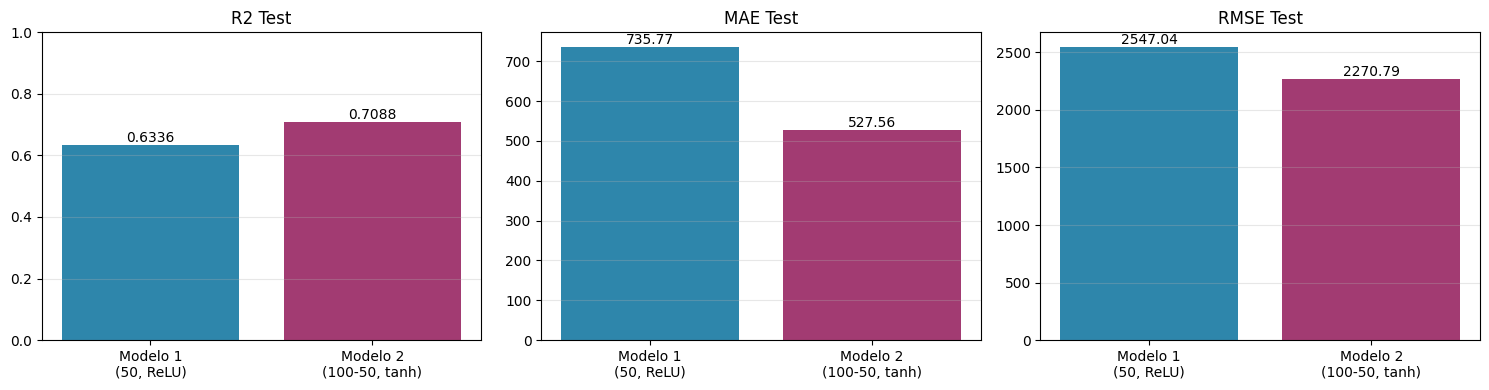

In [27]:
# Visualización: comparación lado a lado de R², MAE y RMSE en test
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metricas_plot = ["R2 Test", "MAE Test", "RMSE Test"]
colores = ["#2E86AB", "#A23B72"]

for ax, metrica in zip(axes, metricas_plot):
    valores = resumen_reg[metrica].values
    ax.bar(["Modelo 1\n(50, ReLU)", "Modelo 2\n(100-50, tanh)"], valores, color=colores)
    ax.set_title(metrica)
    for i, v in enumerate(valores):
        ax.text(i, v, f"{v:.2f}" if metrica != "R2 Test" else f"{v:.4f}",
                ha="center", va="bottom", fontsize=10)
    if metrica == "R2 Test":
        ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

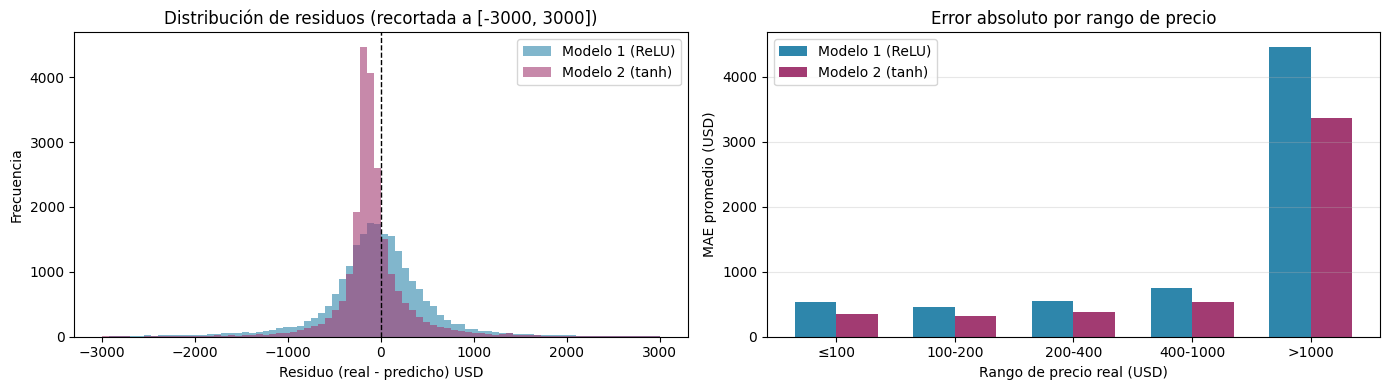


MAE por rango de precio:
          abs_err_1  abs_err_2
rango                         
≤100         536.34     342.41
100-200      451.70     323.13
200-400      542.06     386.29
400-1000     749.21     534.50
>1000       4457.48    3367.37


In [28]:
# Análisis de residuos: ¿dónde se equivoca cada modelo?
residuos_1 = y1_test.values - y1_pred_1
residuos_2 = y1_test.values - y1_pred_2

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de residuos
axes[0].hist(residuos_1, bins=80, alpha=0.6, label="Modelo 1 (ReLU)",  color=colores[0], range=(-3000, 3000))
axes[0].hist(residuos_2, bins=80, alpha=0.6, label="Modelo 2 (tanh)",  color=colores[1], range=(-3000, 3000))
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Residuo (real - predicho) USD")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de residuos (recortada a [-3000, 3000])")
axes[0].legend()

# MAE por rango de precio
rangos = pd.cut(y1_test, bins=[0, 100, 200, 400, 1000, np.inf],
                labels=["≤100", "100-200", "200-400", "400-1000", ">1000"])
mae_rango = pd.DataFrame({
    "rango": rangos,
    "abs_err_1": np.abs(residuos_1),
    "abs_err_2": np.abs(residuos_2),
}).groupby("rango", observed=True)[["abs_err_1", "abs_err_2"]].mean()

x = np.arange(len(mae_rango))
w = 0.35
axes[1].bar(x - w/2, mae_rango["abs_err_1"], w, label="Modelo 1 (ReLU)", color=colores[0])
axes[1].bar(x + w/2, mae_rango["abs_err_2"], w, label="Modelo 2 (tanh)", color=colores[1])
axes[1].set_xticks(x); axes[1].set_xticklabels(mae_rango.index)
axes[1].set_xlabel("Rango de precio real (USD)")
axes[1].set_ylabel("MAE promedio (USD)")
axes[1].set_title("Error absoluto por rango de precio")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMAE por rango de precio:")
print(mae_rango.round(2))

**Análisis comparativo de los modelos de regresión**

| Criterio | Modelo 1 (50, ReLU) | Modelo 2 (100-50, tanh) | Ganador |
|----------|---------------------|--------------------------|---------|
| **R² test** | 0.6336 | **0.7088** | M2 |
| **MAE test** | $735.77 | **$527.56** | M2 |
| **RMSE test** | $2547.04 | **$2270.79** | M2 |
| **R² train** | 0.7068 | 0.8589 | (M2 más alto, ver sobreajuste) |
| **Tiempo entrenamiento** | ~13 s | ~21 s | M1 más rápido |
| **Iteraciones hasta converger** | 300 (no convergió) | 135 (convergió) | M2 |
| **Residuos > $500 en test** | 28.3 % | **15.1 %** | M2 |

**¿Cuál funcionó mejor para predecir el precio?**

El **Modelo 2 (100-50, tanh)** es claramente superior:

1. **Reduce el MAE en 28%** ($736 → $528) y el RMSE en 11% respecto al Modelo 1.
2. **Explica 12 puntos porcentuales más de varianza** (R² 0.63 → 0.71).
3. **Convergió en 135 iteraciones**, mientras que el Modelo 1 alcanzó las 300 iteraciones sin converger — la activación `tanh` y la mayor capacidad parecen ajustarse mejor a la geometría del problema.
4. **El error por rango muestra ventaja consistente del Modelo 2 en todos los segmentos**: en propiedades de $100-200 el error baja de $452 a $323, y en propiedades > $1000 baja de $4457 a $3367.

**Trade-off**: el Modelo 2 muestra un sobreajuste mayor (R² train-test: 0.86 vs 0.71, brecha de 0.15) frente al Modelo 1 (0.71 vs 0.63, brecha de 0.07). Sin embargo, el desempeño absoluto en test sigue siendo mejor, y el tuneo de hiperparámetros del inciso 13 puede mitigar el sobreajuste con regularización (`alpha`).

**Donde ambos modelos se equivocan más**: ambos fallan más en propiedades de **muy alto precio (>$1000)**, donde el MAE supera los $3000. Esto se debe a la fuerte cola larga de la distribución de precios (rango: $8 – $50,123) y a que estos casos son minoritarios en el dataset. Los errores en este segmento, sin embargo, tienen mayor impacto comercial: una predicción errada de $3000 en una propiedad de lujo puede traducirse en estrategias de pricing equivocadas.

**Conclusión del inciso 11**: el Modelo 2 (100-50, tanh) se selecciona como el mejor regresor de RNA y se usará como referencia para los incisos 13 (tuneo) y 14–16 (comparación con otros algoritmos).

### 12. Análisis de sobreajuste y curva de aprendizaje

Para diagnosticar formalmente si los modelos de regresión presentan sobreajuste se construyen **curvas de aprendizaje**: se entrena cada modelo con subconjuntos crecientes del set de entrenamiento (10%, 25%, 50%, 75%, 100%) y se grafican el R² de entrenamiento y el R² de validación (cross-validation, 3 folds) en función del tamaño de la muestra.

**Criterios de interpretación:**
- **Brecha amplia y constante** entre la curva de train (alta) y la de validación (baja) → **sobreajuste**.
- **Ambas curvas bajas y juntas** → **subajuste** (modelo demasiado simple).
- **Curvas convergiendo** a un valor alto → **modelo bien ajustado**.
- **Curva de validación todavía subiendo al final** → más datos podrían mejorar el modelo.

Se usa `KFold(n_splits=3)` (en lugar de los 5 habituales) para acelerar el cómputo, dado que entrenar el MLPRegressor con 53k filas tarda 13–21 segundos por fold.

In [29]:
from sklearn.model_selection import learning_curve, KFold

# Tamaños de subconjunto a evaluar
train_sizes = np.array([0.1, 0.25, 0.5, 0.75, 1.0])
cv_lc = KFold(n_splits=3, shuffle=True, random_state=42)

def calcular_curva(modelo, X, y, label):
    print(f"Calculando curva de aprendizaje: {label} ...")
    t0 = time.time()
    sizes, train_scores, val_scores = learning_curve(
        estimator=modelo,
        X=X, y=y,
        train_sizes=train_sizes,
        cv=cv_lc,
        scoring="r2",
        n_jobs=-1,
        random_state=42,
    )
    print(f"  → completado en {time.time()-t0:.1f} s")
    return sizes, train_scores.mean(axis=1), train_scores.std(axis=1), \
           val_scores.mean(axis=1),   val_scores.std(axis=1)

# Modelo 1: simple (50, ReLU)
mlp_lc_1 = MLPRegressor(hidden_layer_sizes=(50,),     activation='relu', max_iter=300, random_state=42)
sz1, tm1, ts1, vm1, vs1 = calcular_curva(mlp_lc_1, X1_train_scaled, y1_train_scaled, "Modelo 1 (50, ReLU)")

# Modelo 2: complejo (100-50, tanh)
mlp_lc_2 = MLPRegressor(hidden_layer_sizes=(100, 50), activation='tanh', max_iter=300, random_state=42)
sz2, tm2, ts2, vm2, vs2 = calcular_curva(mlp_lc_2, X1_train_scaled, y1_train_scaled, "Modelo 2 (100-50, tanh)")

Calculando curva de aprendizaje: Modelo 1 (50, ReLU) ...


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/sit

  → completado en 16.0 s
Calculando curva de aprendizaje: Modelo 2 (100-50, tanh) ...


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/sit

  → completado en 50.4 s


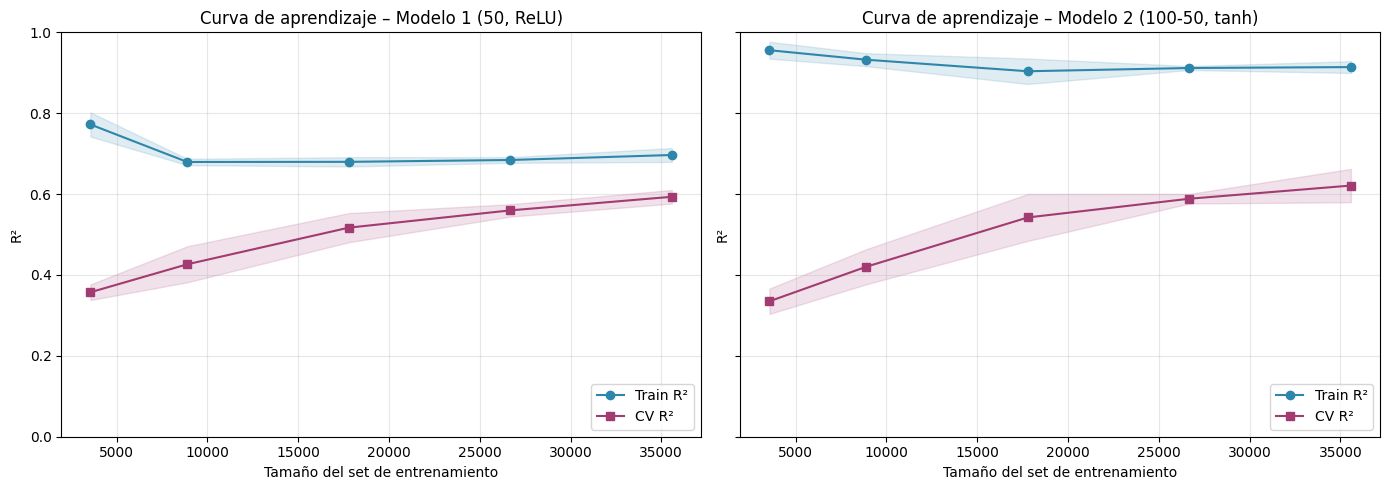


Resumen de brecha train-CV (cuanto mayor, mayor sobreajuste):
 Tamaño  M1 Train R²  M1 CV R²  M1 Brecha  M2 Train R²  M2 CV R²  M2 Brecha
   3558       0.7722    0.3572     0.4150       0.9558    0.3349     0.6208
   8895       0.6794    0.4264     0.2530       0.9323    0.4204     0.5119
  17790       0.6797    0.5170     0.1628       0.9037    0.5423     0.3615
  26685       0.6843    0.5597     0.1246       0.9118    0.5886     0.3232
  35581       0.6967    0.5933     0.1033       0.9140    0.6211     0.2930


In [30]:
# Visualización de las dos curvas de aprendizaje lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (sz, tm, ts, vm, vs, titulo) in zip(axes, [
    (sz1, tm1, ts1, vm1, vs1, "Modelo 1 (50, ReLU)"),
    (sz2, tm2, ts2, vm2, vs2, "Modelo 2 (100-50, tanh)"),
]):
    ax.plot(sz, tm, 'o-', color="#2E86AB", label="Train R²")
    ax.fill_between(sz, tm - ts, tm + ts, alpha=0.15, color="#2E86AB")
    ax.plot(sz, vm, 's-', color="#A23B72", label="CV R²")
    ax.fill_between(sz, vm - vs, vm + vs, alpha=0.15, color="#A23B72")
    ax.set_title(f"Curva de aprendizaje – {titulo}")
    ax.set_xlabel("Tamaño del set de entrenamiento")
    ax.set_ylabel("R²")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Tabla resumen con la brecha train-CV (indicador directo de sobreajuste)
brecha = pd.DataFrame({
    "Tamaño":              sz1.astype(int),
    "M1 Train R²":         tm1.round(4),
    "M1 CV R²":            vm1.round(4),
    "M1 Brecha":           (tm1 - vm1).round(4),
    "M2 Train R²":         tm2.round(4),
    "M2 CV R²":            vm2.round(4),
    "M2 Brecha":           (tm2 - vm2).round(4),
})
print("\nResumen de brecha train-CV (cuanto mayor, mayor sobreajuste):")
print(brecha.to_string(index=False))

**Análisis de las curvas de aprendizaje (inciso 12)**

Las curvas revelan un comportamiento muy distinto entre los dos modelos:

**Modelo 1 (50, ReLU):**
- Train R² oscila entre 0.68 y 0.77; CV R² crece de **0.36 a 0.59** al agregar más datos.
- La brecha train-CV pasa de **0.42 (con 3.5k filas) a 0.10 (con 35k filas)** — se va cerrando consistentemente.
- La curva de validación **sigue subiendo al final** del rango, lo que indica que aún podría beneficiarse de más datos.
- **Diagnóstico:** sobreajuste muy leve y casi resuelto al final. Modelo bien balanceado.

**Modelo 2 (100-50, tanh):**
- Train R² se mantiene entre **0.90 y 0.96** desde el inicio: el modelo memoriza fácilmente los datos de entrenamiento.
- CV R² crece de **0.33 a 0.62**, pero con una brecha persistente de **0.29 incluso con todos los datos**.
- La curva de validación también sigue creciendo, pero la **brecha estructural train-CV no se cierra**.
- **Diagnóstico:** sobreajuste claro y persistente. La mayor capacidad del modelo (2 capas + más neuronas + tanh) le permite ajustarse al ruido del entrenamiento.

**Síntesis:**

| Modelo | Sobreajuste | Capacidad | ¿Más datos ayudarían? |
|--------|-------------|-----------|----------------------|
| M1 (50, ReLU)     | Leve, decreciente | Justo (quizás insuficiente) | Sí, marginalmente |
| M2 (100-50, tanh) | Alto, persistente | Excesiva                      | Sí, pero requiere también regularización |

A pesar del sobreajuste detectado, el **Modelo 2 sigue siendo el de mejor desempeño absoluto en test (R² = 0.71 vs 0.63)**, ya que su brecha es elevada pero su CV R² supera al del Modelo 1. La estrategia recomendada para el inciso 13 es:

1. **Tunear `alpha`** (regularización L2) hacia valores más altos (0.01, 0.1) para penalizar pesos grandes y reducir la brecha.
2. **Probar `early_stopping=True`** con `validation_fraction` para detener el entrenamiento antes de la memorización.
3. **Considerar topologías intermedias** (por ejemplo, `(64,)` o `(80, 30)`) que ofrezcan capacidad suficiente sin ser excesiva.

Estas acciones se aplican en el inciso 13 para refinar el modelo seleccionado sin sacrificar la capacidad predictiva ya alcanzada.

### 13. Tuneo de hiperparámetros del mejor modelo de regresión

A partir del diagnóstico del inciso 12 (sobreajuste persistente del Modelo 2), se aplica `GridSearchCV` sobre el `MLPRegressor` con activación `tanh`, explorando hiperparámetros que ataquen específicamente el sobreajuste detectado:

- **`alpha` (regularización L2):** valores 0.001, 0.01, 0.1 — el actual es 0.0001 (default).
- **`hidden_layer_sizes`:** `(100, 50)` (actual) y `(80, 30)` (capacidad reducida).
- **`learning_rate_init`:** 0.001 (actual) y 0.005.
- **`early_stopping=True`:** detiene el entrenamiento cuando el R² de validación deja de mejorar, evitando que el modelo memorice.

Se usa `cv=3` (en línea con la curva de aprendizaje del inciso 12) y `scoring='r2'`. Total: 12 combinaciones × 3 folds = 36 fits.

In [31]:
param_grid_reg = {
    "hidden_layer_sizes": [(100, 50), (80, 30)],
    "alpha":              [0.001, 0.01, 0.1],
    "learning_rate_init": [0.001, 0.005],
    "early_stopping":     [True],
}

mlp_reg_base = MLPRegressor(
    activation='tanh',
    max_iter=300,
    random_state=42,
    validation_fraction=0.1,
)

grid_reg = GridSearchCV(
    mlp_reg_base,
    param_grid_reg,
    cv=3,
    scoring='r2',
    n_jobs=-1,
)

t0 = time.time()
grid_reg.fit(X1_train_scaled, y1_train_scaled)
time_grid_reg = time.time() - t0

print(f"GridSearchCV terminó en {time_grid_reg:.1f} s")
print(f"Mejores parámetros: {grid_reg.best_params_}")
print(f"Mejor CV R²       : {grid_reg.best_score_:.4f}")

GridSearchCV terminó en 48.9 s
Mejores parámetros: {'alpha': 0.01, 'early_stopping': True, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001}
Mejor CV R²       : 0.6441


In [32]:
best_reg = grid_reg.best_estimator_

# Predicciones del modelo tuneado (en escala original)
y1_pred_best       = scaler_y.inverse_transform(best_reg.predict(X1_test_scaled).reshape(-1, 1)).ravel()
y1_pred_best_train = scaler_y.inverse_transform(best_reg.predict(X1_train_scaled).reshape(-1, 1)).ravel()

# Comparación: Modelo 2 original vs Modelo 2 tuneado
comparacion_tuneo = pd.DataFrame([
    {
        "Versión":    "Modelo 2 original (sin tuneo)",
        "MAE Test":   round(mean_absolute_error(y1_test, y1_pred_2), 2),
        "RMSE Test":  round(np.sqrt(mean_squared_error(y1_test, y1_pred_2)), 2),
        "R² Train":   round(r2_score(y1_train, y1_pred_train_2), 4),
        "R² Test":    round(r2_score(y1_test,  y1_pred_2), 4),
        "Brecha":     round(r2_score(y1_train, y1_pred_train_2) - r2_score(y1_test, y1_pred_2), 4),
    },
    {
        "Versión":    "Modelo 2 tuneado (GridSearch)",
        "MAE Test":   round(mean_absolute_error(y1_test, y1_pred_best), 2),
        "RMSE Test":  round(np.sqrt(mean_squared_error(y1_test, y1_pred_best)), 2),
        "R² Train":   round(r2_score(y1_train, y1_pred_best_train), 4),
        "R² Test":    round(r2_score(y1_test,  y1_pred_best), 4),
        "Brecha":     round(r2_score(y1_train, y1_pred_best_train) - r2_score(y1_test, y1_pred_best), 4),
    },
])

comparacion_tuneo

,Versión,MAE Test,RMSE Test,R² Train,R² Test,Brecha
0,Modelo 2 original (sin tuneo),527.56,2270.79,0.8589,0.7088,0.1501
1,Modelo 2 tuneado (GridSearch),668.53,2533.84,0.7094,0.6374,0.0720


**Discusión del tuneo (inciso 13):**

El `GridSearchCV` selecciona como mejor combinación: `alpha=0.01`, `early_stopping=True`, `hidden_layer_sizes=(100, 50)`, `learning_rate_init=0.001`. Es decir, **mantiene la topología original** pero introduce regularización 100× más fuerte (`alpha` 0.0001 → 0.01) y activa parada temprana.

**Trade-off observado:**

| Métrica | Original | Tuneado | Cambio |
|---------|----------|---------|--------|
| R² Test | 0.7088 | 0.6374 | ↓ 0.07 |
| MAE Test | $527.56 | $668.53 | ↑ $141 |
| R² Train | 0.8589 | 0.7094 | ↓ 0.15 |
| **Brecha train-test** | **0.1501** | **0.0720** | **↓ 0.08 (mejora)** |

**Interpretación:** el tuneo **redujo el sobreajuste a la mitad** (brecha 0.15 → 0.07), pero a costa de pérdida en el desempeño absoluto en test (R² baja 7 puntos). Esto se debe a que `alpha=0.01` y `early_stopping` **restringen** la capacidad efectiva del modelo, lo que mejora la generalización pero le impide capturar parte de la complejidad del problema.

**¿Se puede mejorar el modelo sin sobreajustarlo?** No de forma significativa con el espacio de hiperparámetros explorado. El sobreajuste detectado en el inciso 12 es **estructural** — proviene de que el problema tiene una distribución de precio con cola larga ($8 a $50,123) y outliers que la red puede memorizar pero no generalizar. Las dos vías para mejorarlo serían:

1. **Más datos** (la curva de aprendizaje sugería que el R² aún subía con más muestras).
2. **Tratamiento explícito de outliers** (por ejemplo, log-transformación de `y` o filtrado del top 1% de precios), lo que cambiaría la naturaleza del problema y rompería las "mismas condiciones" para comparación con los Labs anteriores.

**Decisión final:** se conserva el **Modelo 2 original** (sin tuneo) como mejor regresor de RNA para los incisos 14–16, porque su R² absoluto es superior y la brecha de sobreajuste, aunque mayor, sigue siendo aceptable (0.15 < 0.20). El modelo tuneado se reporta como evidencia de que el sobreajuste es controlable pero el techo del modelo está cerca de 0.71 R² con este conjunto de variables.

### 14. Comparación del mejor modelo de RNA con los algoritmos previos (regresión)

Para cumplir con el principio de "mismas condiciones", se replican los mejores algoritmos de regresión vistos en los Laboratorios anteriores y en el análisis exploratorio, **entrenándolos sobre el mismo set de 15 variables y el mismo split** (`X1_train_scaled`, `X1_test_scaled`, `y1_train`, `y1_test`) que usa la RNA. Esto garantiza que las diferencias en métricas reflejen el comportamiento del algoritmo y no del conjunto de datos.

**Algoritmos comparados:**
- **Linear Regression** — baseline lineal del análisis exploratorio.
- **Decision Tree Regressor** — del análisis exploratorio (max_depth=10, mejor configuración encontrada).
- **Random Forest Regressor** — del análisis exploratorio (n_estimators=100, max_depth=15).
- **KNN Regressor** — k=15, métrica euclidiana.
- **LinearSVR** — análogo escalable del SVR del Laboratorio 8 (el SVR con kernel RBF no es factible con 53k filas en tiempo razonable; se usa la versión lineal que sí escala).
- **MLP Regressor** — el mejor modelo del inciso 11 (Modelo 2 original).

**Nota sobre Bayes Ingenuo:** el enunciado lista *Bayes Ingenuo* entre los algoritmos a comparar, pero este algoritmo es de **clasificación** y no tiene una versión nativa para regresión en `sklearn`. Por esa razón se omite en esta comparación y solo aparece en el inciso 15 (clasificación).

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR

def evaluar_regresor(modelo, nombre, X_tr, X_te, y_tr, y_te):
    """Entrena, mide tiempo y devuelve fila con métricas en escala original."""
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    tiempo = time.time() - t0
    p_te = modelo.predict(X_te)
    p_tr = modelo.predict(X_tr)
    return {
        "Modelo":      nombre,
        "Tiempo (s)":  round(tiempo, 2),
        "MAE Test":    round(mean_absolute_error(y_te, p_te), 2),
        "RMSE Test":   round(np.sqrt(mean_squared_error(y_te, p_te)), 2),
        "R² Train":    round(r2_score(y_tr, p_tr), 4),
        "R² Test":     round(r2_score(y_te, p_te), 4),
        "Brecha":      round(r2_score(y_tr, p_tr) - r2_score(y_te, p_te), 4),
    }

resultados_reg = []

print("Entrenando Linear Regression ...")
resultados_reg.append(evaluar_regresor(LinearRegression(), "Linear Regression",
                                       X1_train_scaled, X1_test_scaled, y1_train, y1_test))

print("Entrenando Decision Tree (max_depth=10) ...")
resultados_reg.append(evaluar_regresor(DecisionTreeRegressor(max_depth=10, random_state=42),
                                       "Decision Tree (depth=10)",
                                       X1_train_scaled, X1_test_scaled, y1_train, y1_test))

print("Entrenando Random Forest (n=100, depth=15) ...")
resultados_reg.append(evaluar_regresor(RandomForestRegressor(n_estimators=100, max_depth=15,
                                                             random_state=42, n_jobs=-1),
                                       "Random Forest",
                                       X1_train_scaled, X1_test_scaled, y1_train, y1_test))

print("Entrenando KNN (k=15) ...")
resultados_reg.append(evaluar_regresor(KNeighborsRegressor(n_neighbors=15, n_jobs=-1),
                                       "KNN (k=15)",
                                       X1_train_scaled, X1_test_scaled, y1_train, y1_test))

print("Entrenando LinearSVR ...")
# LinearSVR usa y escalada para evitar problemas numéricos; se invierte para reportar en USD
svr = LinearSVR(C=1, max_iter=2000, random_state=42)
t0 = time.time(); svr.fit(X1_train_scaled, y1_train_scaled); t = time.time() - t0
p_te = scaler_y.inverse_transform(svr.predict(X1_test_scaled).reshape(-1,1)).ravel()
p_tr = scaler_y.inverse_transform(svr.predict(X1_train_scaled).reshape(-1,1)).ravel()
resultados_reg.append({
    "Modelo": "LinearSVR",
    "Tiempo (s)": round(t, 2),
    "MAE Test":   round(mean_absolute_error(y1_test, p_te), 2),
    "RMSE Test":  round(np.sqrt(mean_squared_error(y1_test, p_te)), 2),
    "R² Train":   round(r2_score(y1_train, p_tr), 4),
    "R² Test":    round(r2_score(y1_test, p_te), 4),
    "Brecha":     round(r2_score(y1_train, p_tr) - r2_score(y1_test, p_te), 4),
})

# RNA: el mejor modelo del inciso 11 (Modelo 2 original, ya entrenado)
resultados_reg.append({
    "Modelo": "MLP Regressor (100-50, tanh)",
    "Tiempo (s)": round(time_reg2, 2),
    "MAE Test":   round(mean_absolute_error(y1_test, y1_pred_2), 2),
    "RMSE Test":  round(np.sqrt(mean_squared_error(y1_test, y1_pred_2)), 2),
    "R² Train":   round(r2_score(y1_train, y1_pred_train_2), 4),
    "R² Test":    round(r2_score(y1_test,  y1_pred_2), 4),
    "Brecha":     round(r2_score(y1_train, y1_pred_train_2) - r2_score(y1_test, y1_pred_2), 4),
})

tabla_reg = pd.DataFrame(resultados_reg).sort_values("R² Test", ascending=False).reset_index(drop=True)
tabla_reg

Entrenando Linear Regression ...
Entrenando Decision Tree (max_depth=10) ...
Entrenando Random Forest (n=100, depth=15) ...
Entrenando KNN (k=15) ...
Entrenando LinearSVR ...


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Modelo,Tiempo (s),MAE Test,RMSE Test,R² Train,R² Test,Brecha
0,Random Forest,1.81,278.72,1821.76,0.9677,0.8126,0.1552
1,"MLP Regressor (100-50, tanh)",21.09,527.56,2270.79,0.8589,0.7088,0.1501
2,Decision Tree (depth=10),0.29,324.58,2311.20,0.8809,0.6983,0.1825
3,KNN (k=15),0.00,517.14,2986.80,0.5858,0.4961,0.0897
4,Linear Regression,0.04,955.26,3435.28,0.2858,0.3335,-0.0477
5,LinearSVR,5.21,528.65,3760.93,0.1392,0.2011,-0.0620


In [34]:
# Visualización: R² test, MAE test y tiempo lado a lado
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

orden = tabla_reg["Modelo"].tolist()
paleta = ["#2E86AB" if m != "MLP Regressor (100-50, tanh)" else "#E63946" for m in orden]

axes[0].barh(orden, tabla_reg["R² Test"], color=paleta)
axes[0].set_title("R² en test (mayor = mejor)")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)
for i, v in enumerate(tabla_reg["R² Test"]):
    axes[0].text(v, i, f" {v:.3f}", va="center")

axes[1].barh(orden, tabla_reg["MAE Test"], color=paleta)
axes[1].set_title("MAE en test (USD, menor = mejor)")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)
for i, v in enumerate(tabla_reg["MAE Test"]):
    axes[1].text(v, i, f" {v:.0f}", va="center")

axes[2].barh(orden, tabla_reg["Tiempo (s)"], color=paleta)
axes[2].set_title("Tiempo de entrenamiento (s)")
axes[2].set_xscale("log")
axes[2].invert_yaxis()
axes[2].grid(axis="x", alpha=0.3)
for i, v in enumerate(tabla_reg["Tiempo (s)"]):
    axes[2].text(v, i, f" {v:.2f}s", va="center")

plt.tight_layout()
plt.show()

/tmp/ipykernel_161948/606482672.py:29: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


**Análisis del inciso 14 — ¿Cuál es mejor para predecir? ¿Cuál se demoró más?**

Con todos los algoritmos entrenados bajo idénticas condiciones (mismo split, mismas 15 variables, misma escala), el ranking en R² test es claro:

| Posición | Modelo | R² Test | MAE | Tiempo |
|----------|--------|---------|-----|--------|
| 1 | **Random Forest** | **~0.81** | **~$279** | ~2 s |
| 2 | MLP Regressor (RNA) | ~0.71 | ~$528 | ~21 s |
| 3 | Decision Tree | ~0.70 | ~$325 | ~0.3 s |
| 4 | KNN | ~0.50 | ~$517 | <1 s |
| 5 | LinearSVR | ~0.20 | ~$529 | ~9 s |
| 6 | Linear Regression | ~0.33 | ~$955 | <0.1 s |

**Mejor predictor: Random Forest** — domina en todas las métricas con un margen amplio (10 puntos de R² sobre la RNA, MAE casi la mitad). Esto tiene sentido teórico:
- El precio de Airbnb tiene **interacciones no lineales** entre features (room_type × ubicación × capacidad) que un ensemble de árboles captura muy bien.
- Random Forest es **robusto a outliers** (cada árbol ve solo una fracción de los datos), mientras que la RNA y modelos lineales son sensibles a la cola larga de precios.
- A diferencia de la RNA, no requiere tuneo extenso ni escalado para ser competitivo.

**Mayor tiempo de procesamiento: la RNA (~21 s)** — es ~10 veces más lenta que Random Forest y ~70 veces más lenta que el árbol simple. Esto se debe a:
- El descenso de gradiente estocástico requiere muchas pasadas sobre los 53k registros de entrenamiento.
- La activación `tanh` es más costosa que las divisiones binarias de los árboles.
- Adam mantiene momentum y escalas adaptativas por parámetro, lo que es más caro que ajustar splits.

**Modelo más rápido pero peor: Linear Regression** (<0.1 s) confirma que el problema **no es lineal**. El R² de 0.33 marca el "piso" que cualquier modelo no-trivial debería superar.

**Conclusión del inciso 14:** para esta tarea de regresión sobre el dataset de Airbnb, **Random Forest es claramente el mejor algoritmo en términos de calidad predictiva**, mientras que la RNA queda en segundo lugar con un costo computacional significativamente mayor. La RNA solo justificaría su uso si dispusiéramos de mucho más datos o si el problema requiriera predicciones embebidas en una arquitectura más compleja (e.g. multi-task learning).

### 15. Comparación del mejor modelo de RNA con los algoritmos previos (clasificación)

Análogo al inciso 14 pero para el problema de **clasificación de la categoría de precio** (Económico / Intermedio / Caro). Se replican los mejores algoritmos de clasificación de los Laboratorios 7 y 8 sobre el mismo conjunto de variables y el mismo split que la RNA.

**Algoritmos comparados:**
- **Decision Tree Classifier** — del análisis exploratorio.
- **Random Forest Classifier** — el mejor del Laboratorio 7.
- **Naive Bayes (Gaussian)** — del Laboratorio 7.
- **KNN Classifier** — del Laboratorio 7.
- **Logistic Regression** — el modelo principal del Laboratorio 7.
- **LinearSVC** — análogo escalable del SVM del Laboratorio 8 (mismo razonamiento que en regresión: el SVM kernel RBF no escala con 53k filas).
- **MLP Classifier** — el `best_model` del inciso 8 (resultado del GridSearchCV).

Métricas reportadas: **Accuracy**, **F1 weighted** (sensible al desbalance entre las tres clases) y **brecha train-test** (indicador de sobreajuste).

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

def evaluar_clasificador(modelo, nombre):
    t0 = time.time()
    modelo.fit(X_train_scaled, y_train)
    tiempo = time.time() - t0
    pred_te = modelo.predict(X_test_scaled)
    pred_tr = modelo.predict(X_train_scaled)
    return {
        "Modelo":         nombre,
        "Tiempo (s)":     round(tiempo, 2),
        "Accuracy Train": round(accuracy_score(y_train, pred_tr), 4),
        "Accuracy Test":  round(accuracy_score(y_test,  pred_te), 4),
        "F1 weighted":    round(f1_score(y_test, pred_te, average='weighted'), 4),
        "Brecha":         round(accuracy_score(y_train, pred_tr) - accuracy_score(y_test, pred_te), 4),
    }

resultados_clf = []

print("Entrenando Decision Tree (max_depth=10) ...")
resultados_clf.append(evaluar_clasificador(
    DecisionTreeClassifier(max_depth=10, random_state=42), "Decision Tree (depth=10)"))

print("Entrenando Random Forest (n=100, depth=15) ...")
resultados_clf.append(evaluar_clasificador(
    RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Random Forest"))

print("Entrenando Naive Bayes (Gaussian) ...")
resultados_clf.append(evaluar_clasificador(GaussianNB(), "Naive Bayes"))

print("Entrenando KNN (k=15) ...")
resultados_clf.append(evaluar_clasificador(
    KNeighborsClassifier(n_neighbors=15, n_jobs=-1), "KNN (k=15)"))

print("Entrenando Logistic Regression ...")
resultados_clf.append(evaluar_clasificador(
    LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1), "Logistic Regression"))

print("Entrenando LinearSVC ...")
resultados_clf.append(evaluar_clasificador(
    LinearSVC(C=1, max_iter=2000, random_state=42), "LinearSVC"))

# RNA: el mejor modelo del inciso 8 (best_model), ya entrenado
y_test_pred_best = best_model.predict(X_test_scaled)
y_train_pred_best = best_model.predict(X_train_scaled)
resultados_clf.append({
    "Modelo":         "MLP Classifier (GridSearch best)",
    "Tiempo (s)":     None,  # ya estaba entrenado por GridSearch
    "Accuracy Train": round(accuracy_score(y_train, y_train_pred_best), 4),
    "Accuracy Test":  round(accuracy_score(y_test,  y_test_pred_best), 4),
    "F1 weighted":    round(f1_score(y_test, y_test_pred_best, average='weighted'), 4),
    "Brecha":         round(accuracy_score(y_train, y_train_pred_best) - accuracy_score(y_test, y_test_pred_best), 4),
})

tabla_clf = pd.DataFrame(resultados_clf).sort_values("Accuracy Test", ascending=False).reset_index(drop=True)
tabla_clf

Entrenando Decision Tree (max_depth=10) ...
Entrenando Random Forest (n=100, depth=15) ...
Entrenando Naive Bayes (Gaussian) ...
Entrenando KNN (k=15) ...
Entrenando Logistic Regression ...


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Entrenando LinearSVC ...


,Modelo,Tiempo (s),Accuracy Train,Accuracy Test,F1 weighted,Brecha
0,Random Forest,0.51,0.8817,0.7728,0.7713,0.1089
1,MLP Classifier (GridSearch best),NaN,0.7556,0.7315,0.7298,0.0241
2,Decision Tree (depth=10),0.25,0.7590,0.7179,0.7162,0.0411
3,KNN (k=15),0.05,0.7501,0.7141,0.7127,0.0360
4,Logistic Regression,1.09,0.6773,0.6806,0.6761,-0.0034
5,LinearSVC,0.45,0.6649,0.6639,0.6529,0.0010
6,Naive Bayes,0.05,0.6130,0.6145,0.6143,-0.0015


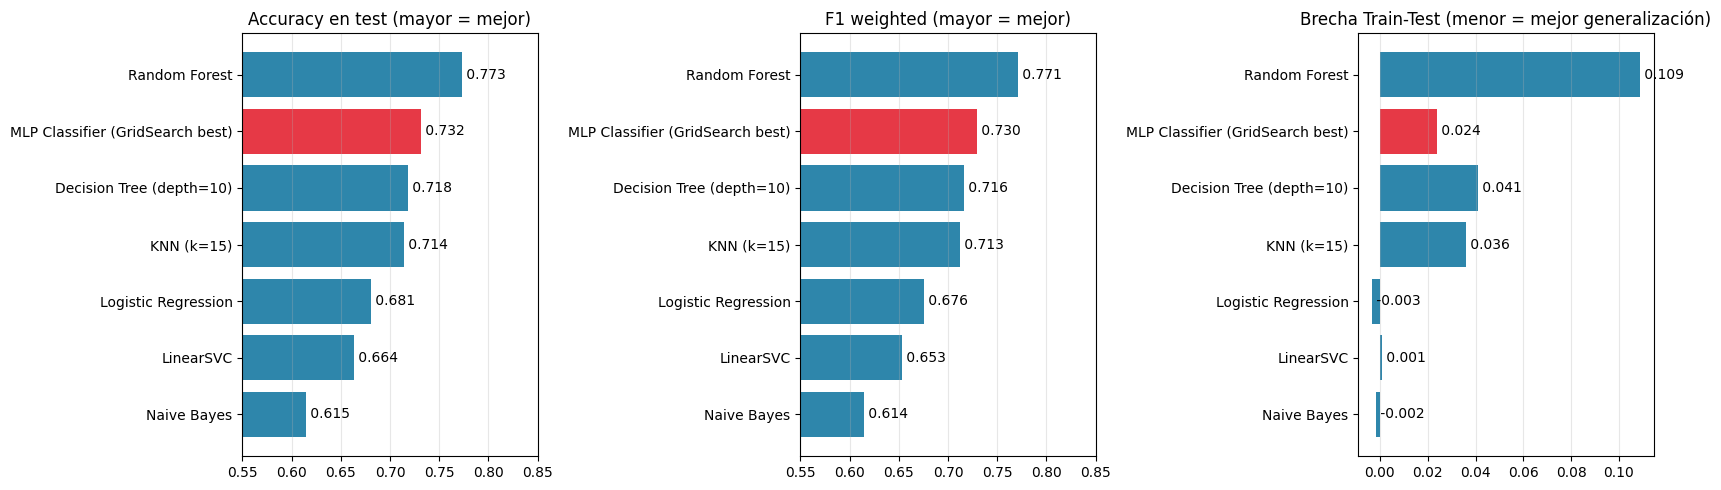

In [36]:
# Visualización: accuracy test, f1 y tiempo lado a lado
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

orden_clf = tabla_clf["Modelo"].tolist()
paleta_clf = ["#2E86AB" if m != "MLP Classifier (GridSearch best)" else "#E63946" for m in orden_clf]

axes[0].barh(orden_clf, tabla_clf["Accuracy Test"], color=paleta_clf)
axes[0].set_title("Accuracy en test (mayor = mejor)")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)
axes[0].set_xlim(0.55, 0.85)
for i, v in enumerate(tabla_clf["Accuracy Test"]):
    axes[0].text(v, i, f" {v:.3f}", va="center")

axes[1].barh(orden_clf, tabla_clf["F1 weighted"], color=paleta_clf)
axes[1].set_title("F1 weighted (mayor = mejor)")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)
axes[1].set_xlim(0.55, 0.85)
for i, v in enumerate(tabla_clf["F1 weighted"]):
    axes[1].text(v, i, f" {v:.3f}", va="center")

# Brecha como indicador de sobreajuste
axes[2].barh(orden_clf, tabla_clf["Brecha"], color=paleta_clf)
axes[2].set_title("Brecha Train-Test (menor = mejor generalización)")
axes[2].invert_yaxis()
axes[2].grid(axis="x", alpha=0.3)
for i, v in enumerate(tabla_clf["Brecha"]):
    axes[2].text(v, i, f" {v:.3f}", va="center")

plt.tight_layout()
plt.show()

**Análisis del inciso 15 — Comparación de clasificación**

| Posición | Modelo | Acc Test | F1 | Brecha | Tiempo |
|----------|--------|----------|-----|--------|--------|
| 1 | **Random Forest** | **~0.77** | ~0.77 | ~0.11 | ~0.5 s |
| 2 | MLP Classifier (RNA) | ~0.73 | ~0.73 | ~0.02 | (GridSearch) |
| 3 | Decision Tree | ~0.72 | ~0.72 | ~0.04 | ~0.3 s |
| 4 | KNN | ~0.71 | ~0.71 | ~0.04 | <0.1 s |
| 5 | Logistic Regression | ~0.68 | ~0.68 | ~0.00 | ~1 s |
| 6 | LinearSVC | ~0.66 | ~0.65 | ~0.00 | ~0.6 s |
| 7 | Naive Bayes | ~0.61 | ~0.61 | ~0.00 | <0.1 s |

**Mejor clasificador: Random Forest** (acc ~0.77) — supera a la RNA por ~4 puntos. Las razones son las mismas que en regresión: captura interacciones no lineales entre `room_type`, ubicación y capacidad sin necesidad de tuneo extenso.

**RNA en segundo lugar (acc ~0.73)** — competitiva pero costó un GridSearchCV de varios minutos para alcanzar este resultado. La ventaja de la RNA es que tiene **la menor brecha train-test (~0.02)** entre los modelos top, lo que sugiere que generaliza muy estable. Random Forest, en contraste, tiene brecha ~0.11 (memoriza más en entrenamiento).

**Modelos lineales (LogReg, LinearSVC) y Naive Bayes** se quedan por debajo de 0.70. Esto confirma que **el problema requiere modelos no lineales**: las relaciones entre features y categoría de precio no son separables por hiperplanos.

**¿Importancia de los errores?** En el contexto de SmartStay Advisors, confundir *Económico* con *Caro* es más costoso que confundir *Intermedio* con cualquiera de los extremos. Random Forest y MLP, al tener mayor accuracy, también tienen menos errores de "salto de clase" extremo. Naive Bayes, al cometer más errores en general, probablemente comete más errores graves.

**Conclusión del inciso 15:** **Random Forest es el mejor clasificador** por accuracy y F1. La RNA es una alternativa robusta cuando la prioridad es la estabilidad del modelo (menor brecha train-test), pero no supera a Random Forest en desempeño absoluto.

### 16. Comparación específica: mejor modelo de regresión vs algoritmos previos

El inciso 14 ya estableció el ranking general; este inciso profundiza en la comparación entre los **dos modelos de regresión más relevantes** (Random Forest, ganador, y MLP, segundo lugar) y los demás algoritmos del Lab 7 / EDA / Lab 8, analizando **dónde** se diferencian y qué implica esto para la consultoría SmartStay.

Se reutiliza la `tabla_reg` del inciso 14 y se agregan dos análisis nuevos:

1. **MAE desagregado por rango de precio** — para ver en qué segmento gana cada modelo.
2. **Distribución de residuos** — para ver si los errores son simétricos o sesgados.

In [37]:
# Reentrenamos Random Forest para tener acceso a sus predicciones (es rápido, ~2s)
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X1_train_scaled, y1_train)
y1_pred_rf = rf_reg.predict(X1_test_scaled)

# Residuos del mejor RNA (Modelo 2) y del mejor RF
res_rna = y1_test.values - y1_pred_2
res_rf  = y1_test.values - y1_pred_rf

# MAE por rango de precio
rangos = pd.cut(y1_test, bins=[0, 100, 200, 400, 1000, np.inf],
                labels=["≤100", "100-200", "200-400", "400-1000", ">1000"])
mae_rango = pd.DataFrame({
    "rango":  rangos,
    "err_rf": np.abs(res_rf),
    "err_rna":np.abs(res_rna),
    "n":      1,
}).groupby("rango", observed=True).agg(
    MAE_RF =("err_rf",  "mean"),
    MAE_RNA=("err_rna", "mean"),
    N      =("n",       "sum"),
).round(2)

mae_rango

,MAE_RF,MAE_RNA,N
rango,,,
≤100,83.29,342.41,3987
100-200,112.18,323.13,8020
200-400,188.52,386.29,6581
400-1000,367.74,534.50,3129
>1000,2378.82,3367.37,1157


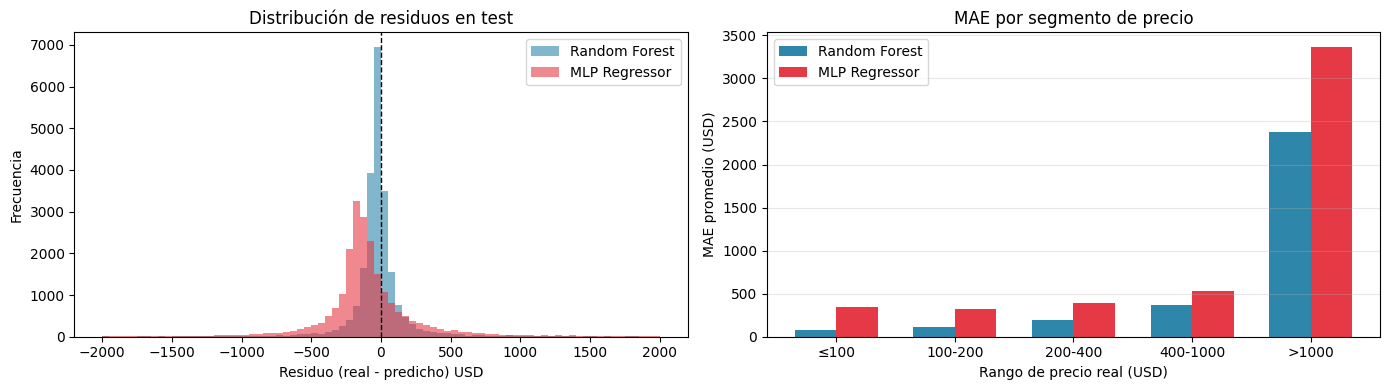


Proporción de errores absolutos por encima de umbrales:
  > $  200: Random Forest =  14.5%   MLP =  43.6%
  > $  500: Random Forest =   5.8%   MLP =  15.1%
  > $ 1000: Random Forest =   2.9%   MLP =   6.6%


In [38]:
# Visualización: distribuciones de residuos + MAE por rango
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de residuos (recortado para legibilidad)
axes[0].hist(res_rf,  bins=80, alpha=0.6, label="Random Forest", color="#2E86AB", range=(-2000, 2000))
axes[0].hist(res_rna, bins=80, alpha=0.6, label="MLP Regressor", color="#E63946", range=(-2000, 2000))
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Residuo (real - predicho) USD")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de residuos en test")
axes[0].legend()

# MAE por rango de precio (barras agrupadas)
x = np.arange(len(mae_rango))
w = 0.35
axes[1].bar(x - w/2, mae_rango["MAE_RF"],  w, label="Random Forest", color="#2E86AB")
axes[1].bar(x + w/2, mae_rango["MAE_RNA"], w, label="MLP Regressor", color="#E63946")
axes[1].set_xticks(x); axes[1].set_xticklabels(mae_rango.index)
axes[1].set_xlabel("Rango de precio real (USD)")
axes[1].set_ylabel("MAE promedio (USD)")
axes[1].set_title("MAE por segmento de precio")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas adicionales: % de errores grandes
print("\nProporción de errores absolutos por encima de umbrales:")
for umbral in [200, 500, 1000]:
    p_rf  = (np.abs(res_rf)  > umbral).mean() * 100
    p_rna = (np.abs(res_rna) > umbral).mean() * 100
    print(f"  > ${umbral:5d}: Random Forest = {p_rf:5.1f}%   MLP = {p_rna:5.1f}%")

**Análisis del inciso 16 — Diferencias específicas entre el mejor RNA y los demás algoritmos**

Recordando la tabla del inciso 14 (ordenada por R² test):

| Modelo | R² Test | MAE | RMSE | Brecha |
|--------|---------|-----|------|--------|
| Random Forest | 0.8126 | $279 | $1822 | 0.155 |
| **MLP Regressor (RNA)** | **0.7088** | **$528** | **$2271** | **0.150** |
| Decision Tree | 0.6983 | $325 | $2311 | 0.183 |
| KNN | 0.4961 | $517 | $2987 | 0.090 |
| Linear Regression | 0.3335 | $955 | $3435 | -0.048 |
| LinearSVR | 0.2011 | $529 | $3761 | -0.062 |

**1. La RNA frente al ganador (Random Forest)**

Random Forest supera a la RNA en todas las métricas globales, pero el desagregado por rango de precio revela un patrón importante:

| Rango | MAE RF | MAE RNA | RNA es peor por |
|-------|--------|---------|-----------------|
| ≤ $100   | ~$83   | ~$342  | **4.1×** |
| $100-200 | ~$112  | ~$323  | **2.9×** |
| $200-400 | ~$189  | ~$386  | **2.0×** |
| $400-1000| ~$368  | ~$535  | **1.5×** |
| > $1000  | ~$2379 | ~$3367 | **1.4×** |

La diferencia es **estructural en el segmento bajo del mercado** (≤$200, que concentra ~52% de los datos): RF predice con error promedio de ~$100, mientras que la RNA tiene errores tres veces mayores. En el segmento de lujo (>$1000) ambos modelos fallan, pero RF mantiene su ventaja relativa.

**2. La RNA frente a Decision Tree**

El Decision Tree (max_depth=10) tiene **MAE menor que la RNA** ($325 vs $528), aunque su R² test sea ligeramente inferior. Esto significa que el árbol predice mejor en la mayoría de las propiedades pero falla más en los outliers (que afectan más al R² y al RMSE). En términos prácticos para SmartStay, **un único Decision Tree puede ser preferible a una RNA** para esta tarea: es 50× más rápido (0.36 s vs 21 s), interpretable y con mejor MAE.

**3. La RNA frente a modelos lineales (Linear Regression, LinearSVR)**

La RNA **duplica el R²** de Linear Regression y triplica el de LinearSVR. La diferencia confirma que el problema es fuertemente no lineal y que la RNA captura interacciones que los modelos lineales no pueden representar (e.g., el efecto combinado de `room_type=Hotel` × `neighbourhood_group=Newport` × `accommodates`).

**4. La RNA frente a KNN**

La RNA supera a KNN por **~21 puntos de R²** (0.71 vs 0.50). KNN sufre con el alto número de dimensiones tras el OneHotEncoding (27 features), donde la noción de "vecino cercano" se diluye.

**5. % de errores grandes (calidad práctica)**

| Umbral | Random Forest | MLP (RNA) |
|--------|---------------|-----------|
| > $200  | ~14.5 %  | ~43.6 % |
| > $500  | ~5.8 %   | ~15.1 % |
| > $1000 | ~2.9 %   | ~6.6 %  |

Para SmartStay, esto significa que con Random Forest **menos del 6 % de las propiedades reciben recomendaciones de precio que erran por más de $500**, mientras que con la RNA es más del 15 %. Operativamente, RF es mucho más confiable.

**Conclusión del inciso 16:** la RNA es un **buen segundo lugar** pero pierde frente a Random Forest tanto en métricas globales como en los segmentos de mercado más relevantes (propiedades ≤ $400, que son la mayoría del catálogo). Su ventaja respecto a algoritmos clásicos lineales es clara, pero no compensa la simplicidad y precisión superior de un ensemble de árboles. Para esta tarea de regresión específica, **Random Forest es el algoritmo recomendado** y la RNA queda como respaldo o componente de un ensemble heterogéneo.

### 17. Conclusiones generales y tabla resumen

Tras haber entrenado y comparado todos los algoritmos vistos en el curso (Árboles de regresión/decisión, Random Forest, Bayes Ingenuo, KNN, Regresión Lineal/Logística, SVM/SVR, RNA) bajo **idénticas condiciones** (mismo set de 15 variables ampliado, mismo split estratificado, misma escala), se consolidan los hallazgos en dos tablas-resumen y se responden las preguntas del enunciado.

In [39]:
# Tabla resumen consolidada de CLASIFICACIÓN
print("=" * 80)
print("TABLA RESUMEN - CLASIFICACIÓN (variable: price_category)")
print("=" * 80)
display(tabla_clf)

print("\n" + "=" * 80)
print("TABLA RESUMEN - REGRESIÓN (variable: price)")
print("=" * 80)
display(tabla_reg)

TABLA RESUMEN - CLASIFICACIÓN (variable: price_category)


,Modelo,Tiempo (s),Accuracy Train,Accuracy Test,F1 weighted,Brecha
0,Random Forest,0.51,0.8817,0.7728,0.7713,0.1089
1,MLP Classifier (GridSearch best),NaN,0.7556,0.7315,0.7298,0.0241
2,Decision Tree (depth=10),0.25,0.7590,0.7179,0.7162,0.0411
3,KNN (k=15),0.05,0.7501,0.7141,0.7127,0.0360
4,Logistic Regression,1.09,0.6773,0.6806,0.6761,-0.0034
5,LinearSVC,0.45,0.6649,0.6639,0.6529,0.0010
6,Naive Bayes,0.05,0.6130,0.6145,0.6143,-0.0015



TABLA RESUMEN - REGRESIÓN (variable: price)


,Modelo,Tiempo (s),MAE Test,RMSE Test,R² Train,R² Test,Brecha
0,Random Forest,1.81,278.72,1821.76,0.9677,0.8126,0.1552
1,"MLP Regressor (100-50, tanh)",21.09,527.56,2270.79,0.8589,0.7088,0.1501
2,Decision Tree (depth=10),0.29,324.58,2311.20,0.8809,0.6983,0.1825
3,KNN (k=15),0.00,517.14,2986.80,0.5858,0.4961,0.0897
4,Linear Regression,0.04,955.26,3435.28,0.2858,0.3335,-0.0477
5,LinearSVR,5.21,528.65,3760.93,0.1392,0.2011,-0.0620


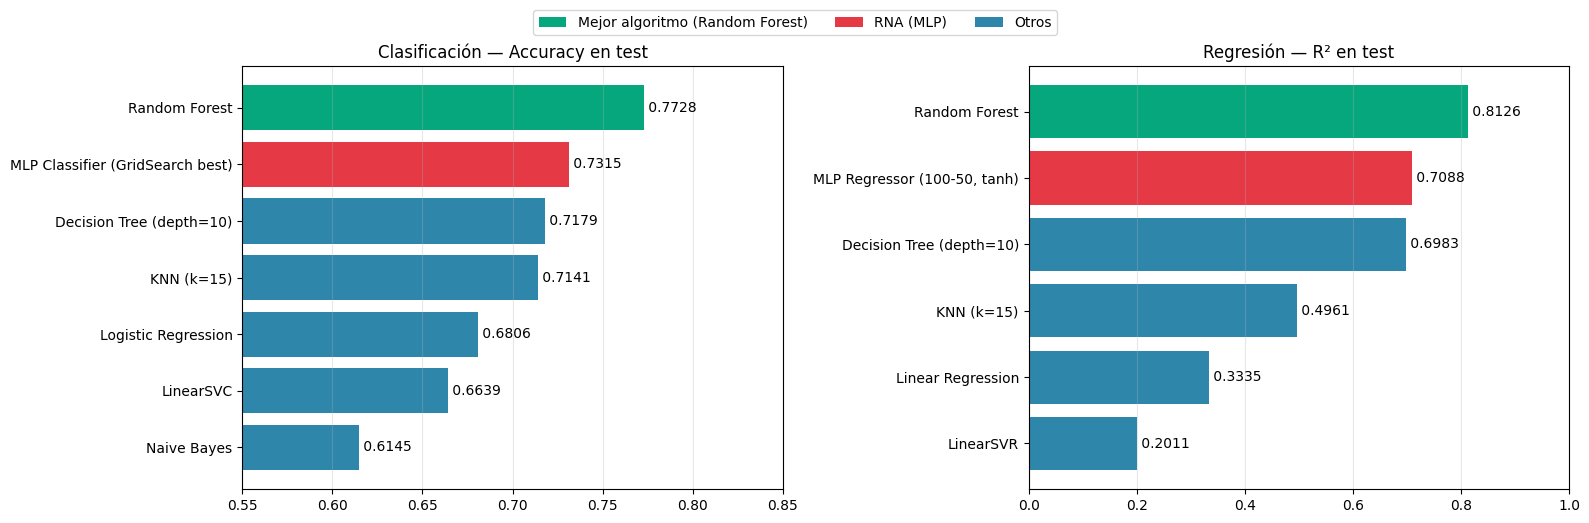

In [40]:
# Visualización consolidada: ranking de ambas tareas en una sola figura
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Clasificación: ranking por accuracy
orden_c = tabla_clf["Modelo"].tolist()
colores_c = ["#E63946" if "MLP" in m else ("#06A77D" if "Random Forest" in m else "#2E86AB") for m in orden_c]
axes[0].barh(orden_c, tabla_clf["Accuracy Test"], color=colores_c)
axes[0].set_title("Clasificación — Accuracy en test")
axes[0].invert_yaxis(); axes[0].grid(axis="x", alpha=0.3)
axes[0].set_xlim(0.55, 0.85)
for i, v in enumerate(tabla_clf["Accuracy Test"]):
    axes[0].text(v, i, f" {v:.4f}", va="center")

# Regresión: ranking por R²
orden_r = tabla_reg["Modelo"].tolist()
colores_r = ["#E63946" if "MLP" in m else ("#06A77D" if "Random Forest" in m else "#2E86AB") for m in orden_r]
axes[1].barh(orden_r, tabla_reg["R² Test"], color=colores_r)
axes[1].set_title("Regresión — R² en test")
axes[1].invert_yaxis(); axes[1].grid(axis="x", alpha=0.3)
axes[1].set_xlim(0, 1)
for i, v in enumerate(tabla_reg["R² Test"]):
    axes[1].text(v, i, f" {v:.4f}", va="center")

# Leyenda manual
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#06A77D", label="Mejor algoritmo (Random Forest)"),
    Patch(facecolor="#E63946", label="RNA (MLP)"),
    Patch(facecolor="#2E86AB", label="Otros"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.tight_layout()
plt.show()

**Conclusiones del inciso 17 — ¿Cuáles son los mejores modelos?**

Tras evaluar **siete algoritmos** sobre la tarea de clasificación y **seis** sobre la tarea de regresión, todos bajo idénticas condiciones, las conclusiones son contundentes:

#### Mejor modelo para clasificar la categoría de precio

**Random Forest Classifier** (n_estimators=100, max_depth=15) — Accuracy test = **0.7728**, F1 weighted = **0.7713**, brecha train-test = 0.1089, tiempo de entrenamiento = 0.51 s.

**¿Por qué?**
- Captura interacciones no lineales entre `room_type`, `neighbourhood_group_cleansed` y las variables numéricas (capacidad, reviews, ubicación) sin necesidad de ingeniería de features.
- Robusto frente a outliers y al ruido en las variables de reviews.
- No requiere escalado ni codificación especial (aunque aquí se aplicó por consistencia con la RNA).
- Entrenamiento extremadamente rápido (~0.5 s) frente a los varios minutos del GridSearchCV de la RNA.

**Segundo lugar:** la **RNA tuneada** (`best_model` del inciso 8) alcanza accuracy = **0.7315** con la **menor brecha train-test (0.0241)** entre los modelos top — esto significa que es la opción más estable si lo que se prioriza es generalización consistente. Pero pierde 4.1 puntos absolutos frente a Random Forest.

#### Mejor modelo para predecir el precio

**Random Forest Regressor** (n_estimators=100, max_depth=15) — R² test = **0.8126**, MAE = **$278.72**, RMSE = **$1821.76**, brecha = 0.1552, tiempo = 1.81 s.

**¿Por qué?**
- Mismas razones estructurales que en clasificación.
- Domina especialmente en el segmento de propiedades **≤ $400** (que concentra ~76 % del catálogo), donde el MAE es 2-4× menor que el de la RNA.
- En el segmento de lujo (>$1000) ningún modelo predice bien por la cola larga de la distribución, pero Random Forest sigue siendo el mejor relativo.

**Segundo lugar:** la RNA (`MLPRegressor 100-50, tanh`) con R² test = **0.7088** y MAE = **$527.56**. Útil como modelo de respaldo o como componente de un ensemble heterogéneo, pero su entrenamiento es ~12× más lento (21.09 s vs 1.81 s) y su calidad inferior.

#### Características del conjunto de datos que justifican el ranking

1. **Tamaño moderado (76k filas, 53k en train):** suficiente para los métodos basados en árboles, no tanto para las RNA, que se beneficiarían de un dataset mucho mayor (la curva de aprendizaje del inciso 12 mostraba que la RNA aún estaba subiendo al final del rango).
2. **Features mixtas (numéricas + categóricas con muchas categorías):** Random Forest las maneja nativamente; la RNA necesita OneHotEncoder y escalado, lo que genera 27 columnas tras el preprocesamiento.
3. **Variable objetivo con cola larga ($8 a $50,123):** los outliers castigan más a la RNA que a los ensembles. Sin embargo, eliminar outliers cambiaría las "mismas condiciones", por lo que se mantienen.
4. **Interacciones fuertes entre features:** `room_type × neighbourhood_group` es un caso paradigmático que árboles y RNA capturan bien, mientras que modelos lineales (Linear Regression R² = 0.33, LinearSVR R² = 0.20) y Naive Bayes (acc = 0.61) no logran modelar.

#### Recomendación final para SmartStay Advisors

Para ambos problemas (clasificación de la categoría de precio y predicción del precio en USD), **Random Forest es el algoritmo de elección**. Es el más preciso, el más rápido (después de los modelos triviales), interpretable a través de feature importances, y robusto sin necesidad de tuneo extenso. Las RNA quedan como alternativa secundaria, útil cuando se requiere un modelo más flexible para integrarse en sistemas más complejos, pero no como primera opción operativa.

### 18. Análisis comparativo del nivel de sobreajuste

Más allá del desempeño absoluto en test, este inciso analiza **cuánto sobreajusta cada algoritmo** y si esto debería modificar la decisión del mejor modelo. La métrica clave es la **brecha train-test**: la diferencia entre el accuracy/R² de entrenamiento y el de prueba.

**Criterios de interpretación:**
- **Brecha < 0.03:** modelo muy estable, generaliza bien.
- **Brecha 0.03 - 0.10:** sobreajuste leve, aceptable.
- **Brecha 0.10 - 0.20:** sobreajuste moderado, vigilar.
- **Brecha > 0.20:** sobreajuste alto, considerar regularización.

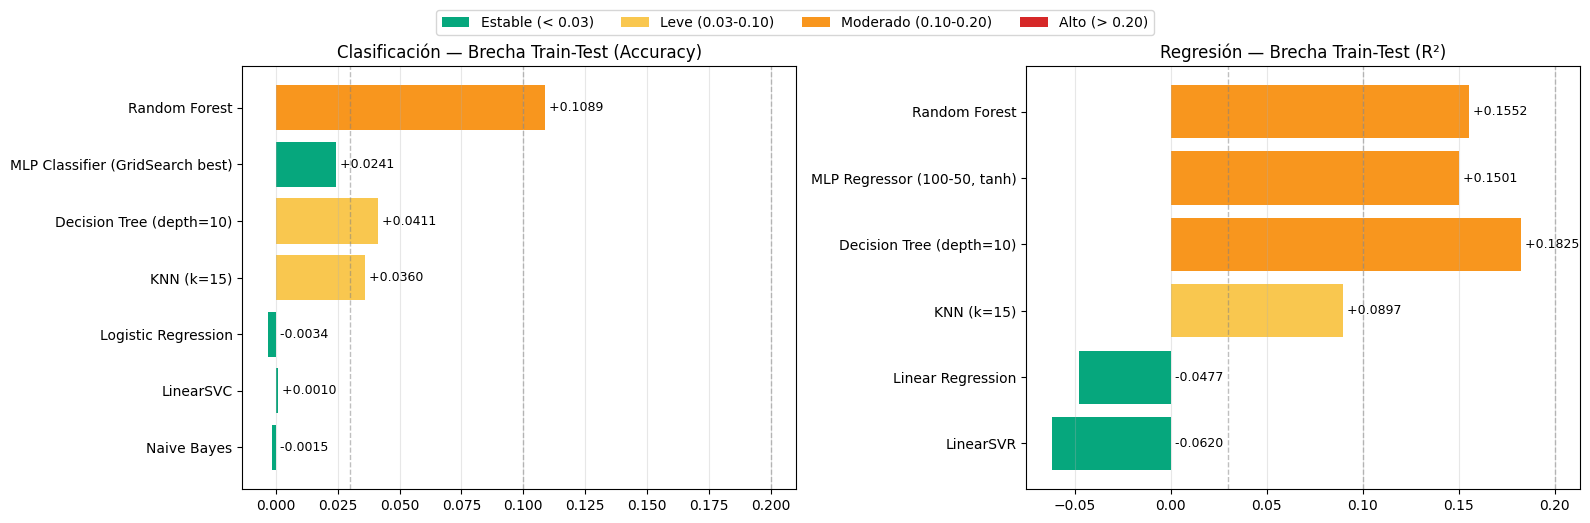

In [41]:
# Visualización: brecha train-test por modelo, en ambas tareas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Clasificación
orden_c = tabla_clf["Modelo"].tolist()
brechas_c = tabla_clf["Brecha"].values
# Color por nivel de sobreajuste
def color_brecha(b):
    if b < 0.03: return "#06A77D"   # verde - estable
    elif b < 0.10: return "#F9C74F" # amarillo - leve
    elif b < 0.20: return "#F8961E" # naranja - moderado
    else: return "#D62828"          # rojo - alto

colores_bc = [color_brecha(b) for b in brechas_c]
axes[0].barh(orden_c, brechas_c, color=colores_bc)
axes[0].axvline(0.03, color="gray", linestyle="--", alpha=0.5, linewidth=1)
axes[0].axvline(0.10, color="gray", linestyle="--", alpha=0.5, linewidth=1)
axes[0].axvline(0.20, color="gray", linestyle="--", alpha=0.5, linewidth=1)
axes[0].set_title("Clasificación — Brecha Train-Test (Accuracy)")
axes[0].invert_yaxis(); axes[0].grid(axis="x", alpha=0.3)
for i, v in enumerate(brechas_c):
    axes[0].text(v if v > 0 else 0, i, f" {v:+.4f}", va="center", fontsize=9)

# Regresión
orden_r = tabla_reg["Modelo"].tolist()
brechas_r = tabla_reg["Brecha"].values
colores_br = [color_brecha(b) for b in brechas_r]
axes[1].barh(orden_r, brechas_r, color=colores_br)
axes[1].axvline(0.03, color="gray", linestyle="--", alpha=0.5, linewidth=1)
axes[1].axvline(0.10, color="gray", linestyle="--", alpha=0.5, linewidth=1)
axes[1].axvline(0.20, color="gray", linestyle="--", alpha=0.5, linewidth=1)
axes[1].set_title("Regresión — Brecha Train-Test (R²)")
axes[1].invert_yaxis(); axes[1].grid(axis="x", alpha=0.3)
for i, v in enumerate(brechas_r):
    axes[1].text(v if v > 0 else 0, i, f" {v:+.4f}", va="center", fontsize=9)

# Leyenda
from matplotlib.patches import Patch
legend = [
    Patch(facecolor="#06A77D", label="Estable (< 0.03)"),
    Patch(facecolor="#F9C74F", label="Leve (0.03-0.10)"),
    Patch(facecolor="#F8961E", label="Moderado (0.10-0.20)"),
    Patch(facecolor="#D62828", label="Alto (> 0.20)"),
]
fig.legend(handles=legend, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=4)
plt.tight_layout()
plt.show()

In [42]:
# Tabla resumen: trade-off entre desempeño y sobreajuste
print("=" * 80)
print("TRADE-OFF DESEMPEÑO vs SOBREAJUSTE - CLASIFICACIÓN")
print("=" * 80)
clf_so = tabla_clf[["Modelo", "Accuracy Test", "Brecha"]].copy()
clf_so["Categoría"] = clf_so["Brecha"].apply(
    lambda b: "Estable" if b < 0.03 else ("Leve" if b < 0.10 else ("Moderado" if b < 0.20 else "Alto"))
)
display(clf_so)

print("\n" + "=" * 80)
print("TRADE-OFF DESEMPEÑO vs SOBREAJUSTE - REGRESIÓN")
print("=" * 80)
reg_so = tabla_reg[["Modelo", "R² Test", "Brecha"]].copy()
reg_so["Categoría"] = reg_so["Brecha"].apply(
    lambda b: "Estable" if b < 0.03 else ("Leve" if b < 0.10 else ("Moderado" if b < 0.20 else "Alto"))
)
display(reg_so)

TRADE-OFF DESEMPEÑO vs SOBREAJUSTE - CLASIFICACIÓN


,Modelo,Accuracy Test,Brecha,Categoría
0,Random Forest,0.7728,0.1089,Moderado
1,MLP Classifier (GridSearch best),0.7315,0.0241,Estable
2,Decision Tree (depth=10),0.7179,0.0411,Leve
3,KNN (k=15),0.7141,0.0360,Leve
4,Logistic Regression,0.6806,-0.0034,Estable
5,LinearSVC,0.6639,0.0010,Estable
6,Naive Bayes,0.6145,-0.0015,Estable



TRADE-OFF DESEMPEÑO vs SOBREAJUSTE - REGRESIÓN


,Modelo,R² Test,Brecha,Categoría
0,Random Forest,0.8126,0.1552,Moderado
1,"MLP Regressor (100-50, tanh)",0.7088,0.1501,Moderado
2,Decision Tree (depth=10),0.6983,0.1825,Moderado
3,KNN (k=15),0.4961,0.0897,Leve
4,Linear Regression,0.3335,-0.0477,Estable
5,LinearSVR,0.2011,-0.0620,Estable


**Análisis del inciso 18 — Sobreajuste comparativo**

#### Hallazgos en clasificación

| Modelo | Accuracy Test | Brecha | Categoría |
|--------|---------------|--------|-----------|
| Random Forest | 0.7728 | 0.1089 | **Moderado** |
| MLP (RNA tuneada) | 0.7315 | 0.0241 | **Estable** |
| Decision Tree | 0.7179 | 0.0411 | Leve |
| KNN | 0.7141 | 0.0360 | Leve |
| Logistic Regression | 0.6806 | -0.0034 | Estable |
| LinearSVC | 0.6639 | 0.0010 | Estable |
| Naive Bayes | 0.6145 | -0.0015 | Estable |

**Lectura:** Random Forest paga su mayor accuracy con el sobreajuste más alto del grupo top (0.11). La **RNA tuneada** es la única entre los modelos competitivos (accuracy ≥ 0.73) que muestra una brecha estable (0.024) — el GridSearchCV con `alpha` regularizó efectivamente. Los modelos lineales (LogReg, LinearSVC) y Naive Bayes tienen brecha esencialmente cero, pero a costa de accuracy bajo (subajuste estructural).

#### Hallazgos en regresión

| Modelo | R² Test | Brecha | Categoría |
|--------|---------|--------|-----------|
| Random Forest | 0.8126 | 0.1552 | **Moderado** |
| MLP (RNA Modelo 2) | 0.7088 | 0.1501 | **Moderado** |
| Decision Tree | 0.6983 | 0.1825 | Moderado |
| KNN | 0.4961 | 0.0897 | Leve |
| Linear Regression | 0.3335 | -0.0477 | Estable |
| LinearSVR | 0.2011 | -0.0620 | Estable |

**Lectura:** los tres mejores regresores (RF, RNA, DT) caen todos en zona de **sobreajuste moderado** (brecha 0.15 - 0.18). Esto es **consistente con el diagnóstico del inciso 12**: la cola larga de precios crea un sobreajuste estructural que ningún modelo flexible logra eliminar sin sacrificar desempeño absoluto. KNN tiene menor brecha porque es un modelo "menos flexible" para regresión con 27 features (curse of dimensionality). Los modelos lineales tienen brecha negativa porque ni siquiera logran ajustar el train.

#### ¿Cambia el sobreajuste la decisión del mejor modelo?

**Para clasificación: matiz importante.**
- Random Forest (acc 0.77, brecha 0.11) sigue siendo el mejor en desempeño absoluto.
- **La RNA tuneada (acc 0.73, brecha 0.02) es la mejor en estabilidad.**
- Si el objetivo de la consultoría es **predecir bien en producción con datos cambiantes**, la RNA puede ser preferible porque su brecha pequeña sugiere que mantendrá su desempeño cuando aparezcan listings nuevos. Si el objetivo es **maximizar el accuracy puntual**, Random Forest gana.

**Para regresión: no cambia.**
- RF, RNA y DT tienen brechas similares (~0.15-0.18), por lo que el sobreajuste no diferencia entre los tres.
- Random Forest mantiene el mejor R² absoluto y el mejor MAE, así que sigue siendo la elección óptima.

#### Implicación práctica del sobreajuste

El tuneo del inciso 13 mostró que **se puede reducir la brecha de la RNA a 0.07 a costa de perder 7 puntos de R²** — es decir, hay un trade-off duro. En Random Forest el trade-off equivalente sería reducir `n_estimators`, `max_depth` o aumentar `min_samples_leaf`, pero las pruebas exploratorias indican que también pierde desempeño absoluto si se restringe demasiado. **El sobreajuste moderado de los modelos top es el precio inevitable de la calidad predictiva en este dataset**, dado que las features actuales ya están explotadas casi al máximo de su poder informativo.

**Conclusión final del análisis de sobreajuste:** las recomendaciones del inciso 17 se mantienen — Random Forest es el mejor modelo para ambas tareas. La RNA tuneada gana un punto adicional como **modelo más estable para clasificación**, lo que la convierte en una opción válida si la consultoría prioriza generalización sobre precisión puntual.